In [ ]:
import xrayutilities as xu
import matplotlib.pyplot as plt
from pathlib import Path
from pybaselines import Baseline, utils
import numpy as np

In [73]:
# Load XRDML file
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\XRD\new_XRD")
patterns = ['*_1.xrdml','*_2.xrdml','*_A1.xrdml','*_A2.xrdml']
file_list = []

In [74]:
for p in patterns:
    file_list.extend(list(main_dir.rglob(p)))
datasets = []

for filename in file_list:
    data = xu.io.XRDMLFile(str(filename))
    xrd_data = {
        'name': filename.name,
        'two_theta': data.scan['2Theta'],
        'intensity_original': data.scan['detector']*data.scan['countTime'],
        'intensity_filtered' : None,
        'k_alpha_1': 1.5405980,
        'k_alpha_2': 1.5444260,
        'k_alpha': (2*1.5405980 + 1.5444260)/3,
        'LDH_basal_spacing': None
    }

    datasets.append ({'xrd_data':xrd_data})


In [75]:
for data in datasets:
    baseline_fitter = Baseline(x_data=data['xrd_data']['two_theta'])
    bkg_4, params_4 = baseline_fitter.mor(data['xrd_data']['intensity_original'])
    data['xrd_data']['intensity_filtered'] = data['xrd_data']['intensity_original'] - bkg_4
    
    mask = np.array(data['xrd_data']['two_theta']) < 15
    two_theta_cut = data['xrd_data']['two_theta'][mask]
    intensity_cut = data['xrd_data']['intensity_original'][mask]
    
    idx_max = np.argmax(intensity_cut)
    best_two_theta = two_theta_cut[idx_max]
    theta_radians = np.radians(best_two_theta / 2)
    
    wavelength = data['xrd_data']['k_alpha']
    basal_spacing = wavelength / (2 * np.sin(theta_radians))
    
    data['xrd_data']['LDH_basal_spacing'] = basal_spacing
    


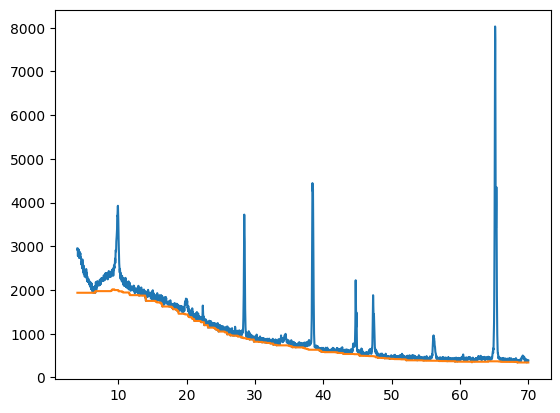

In [92]:
baseline_fitter = Baseline(x_data=datasets[2]['xrd_data']['two_theta'])
bkg_4, params_4 = baseline_fitter.mor(datasets[2]['xrd_data']['intensity_original'])
plt.plot(datasets[2]['xrd_data']['two_theta'],datasets[2]['xrd_data']['intensity_original'])
plt.plot(datasets[2]['xrd_data']['two_theta'],bkg_4)
plt.show()


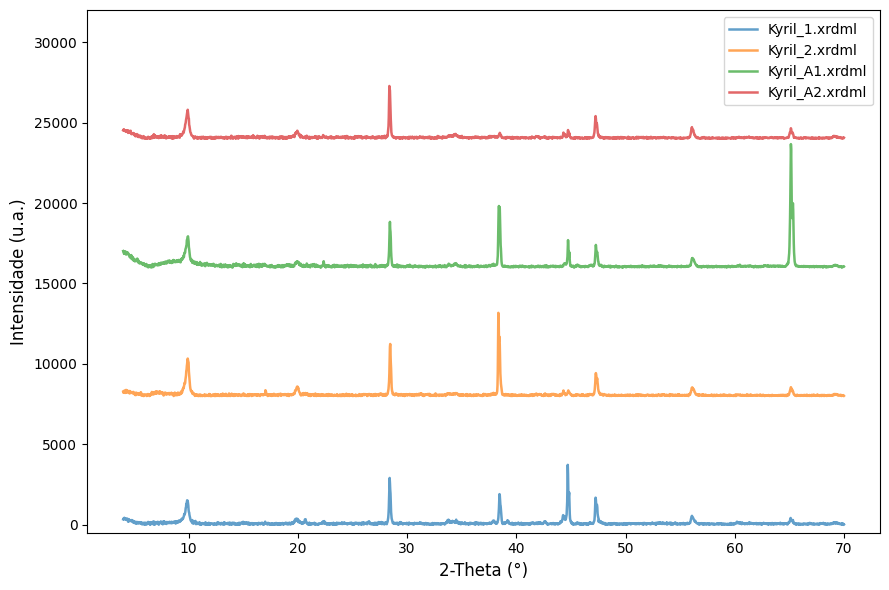

In [102]:
plt.figure(figsize=(9, 6))

offset = 8000

for i, data in enumerate(datasets):
    plt.plot(
        data['xrd_data']['two_theta'], 
        data['xrd_data']['intensity_filtered'] + (offset * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=data['xrd_data']['name']
    )    

#plt.xlim(5, 20)
plt.ylim(-500,32000)

plt.xlabel('2-Theta (°)', fontsize=12)
plt.ylabel('Intensidade (u.a.)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()    

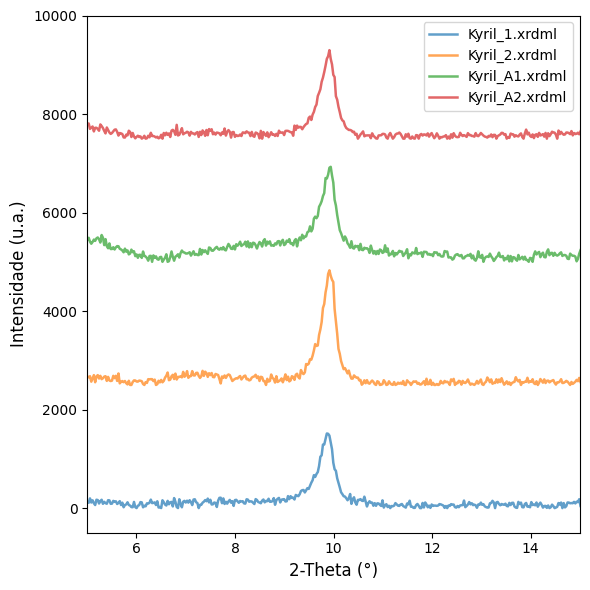

In [114]:
plt.figure(figsize=(6, 6))

offset = 2500

for i, data in enumerate(datasets):
    plt.plot(
        data['xrd_data']['two_theta'], 
        data['xrd_data']['intensity_filtered'] + (offset * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=data['xrd_data']['name']
    )    

plt.xlim(5, 15)
plt.ylim(-500,10000)

plt.xlabel('2-Theta (°)', fontsize=12)
plt.ylabel('Intensidade (u.a.)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()   